# Multivariate Forecasting End-to-End Notebook

This notebook gives you a **ready-to-run template** for multivariate time series forecasting with:

- dataset loading and schema checks
- cleaning and preprocessing
- feature engineering for forecasting
- train / validation / test split
- statistical and ML-friendly diagnostics
- rolling-origin **backtesting**
- final evaluation on a holdout test set

It is designed to work out of the box with the included sample dataset, and you can swap in your own CSV by changing the config cell.


In [ ]:
# Install once if needed
# %pip install pandas numpy scikit-learn matplotlib statsmodels jupyter


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import List, Tuple, Dict

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.stattools import adfuller


## 1) Configuration

Update these values when using your own dataset.


In [3]:
DATA_PATH = r"multivariate_forecasting_sample.csv"

CONFIG = {
    "datetime_col": "date",
    "target_cols": ["units_sold", "revenue"],  # forecast one or more targets
    "exogenous_cols": ["marketing_spend", "price", "inventory_level", "website_sessions", "returns", "holiday_flag"],
    "freq": "D",
    "forecast_horizon": 14,
    "lags": [1, 7, 14, 28],
    "rolling_windows": [7, 14, 28],
    "test_size": 60,
    "n_backtest_folds": 4,
    "backtest_step": 14,
    "drop_duplicates": True
}
CONFIG


{'datetime_col': 'date',
 'target_cols': ['units_sold', 'revenue'],
 'exogenous_cols': ['marketing_spend',
  'price',
  'inventory_level',
  'website_sessions',
  'returns',
  'holiday_flag'],
 'freq': 'D',
 'forecast_horizon': 14,
 'lags': [1, 7, 14, 28],
 'rolling_windows': [7, 14, 28],
 'test_size': 60,
 'n_backtest_folds': 4,
 'backtest_step': 14,
 'drop_duplicates': True}

## 2) Load data

In [6]:
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())


Raw shape: (1466, 9)


,date,units_sold,revenue,marketing_spend,price,inventory_level,website_sessions,returns,holiday_flag
0,2024-12-30,185.19,3824.86,55.74,20.60,289.51,1121.80,10.51,1
1,2022-06-23,124.90,2527.85,41.76,20.26,301.20,915.19,11.05,0
2,2023-08-17,137.11,2726.66,41.72,19.85,296.38,1010.52,7.51,0
3,2024-08-26,163.52,3332.79,59.74,20.26,308.86,1140.81,9.44,0
4,2024-06-02,175.33,3396.75,59.29,19.36,309.55,1153.66,11.08,0


## 3) Initial data checks and preprocessing

In [7]:
def initial_preprocess(df: pd.DataFrame, config: Dict) -> pd.DataFrame:
    df = df.copy()
    dt_col = config["datetime_col"]

    # parse datetime
    df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")

    # drop completely invalid dates
    df = df.dropna(subset=[dt_col])

    # drop duplicates
    if config.get("drop_duplicates", True):
        before = len(df)
        df = df.drop_duplicates()
        print(f"Dropped duplicates: {before - len(df)}")

    # sort
    df = df.sort_values(dt_col).reset_index(drop=True)

    # numeric conversion where possible
    for col in config["target_cols"] + config["exogenous_cols"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

df = initial_preprocess(df_raw, CONFIG)
print("Processed shape:", df.shape)
display(df.head())


Dropped duplicates: 5
Processed shape: (1461, 9)


,date,units_sold,revenue,marketing_spend,price,inventory_level,website_sessions,returns,holiday_flag
0,2022-01-01,125.09,2455.80,52.48,19.51,298.83,1049.90,5.10,0
1,2022-01-02,123.83,2495.89,51.39,20.13,302.09,1079.36,9.94,0
2,2022-01-03,136.52,2738.15,57.31,20.05,305.25,1107.66,10.82,0
3,2022-01-04,122.44,2491.80,63.49,20.26,307.99,1058.05,7.41,0
4,2022-01-05,116.12,2400.81,56.26,20.72,306.91,952.99,7.32,0


In [8]:
def schema_report(df: pd.DataFrame, config: Dict) -> pd.DataFrame:
    cols = [config["datetime_col"]] + config["target_cols"] + config["exogenous_cols"]
    report = pd.DataFrame({
        "column": cols,
        "dtype": [df[c].dtype if c in df.columns else "MISSING" for c in cols],
        "missing_count": [df[c].isna().sum() if c in df.columns else None for c in cols],
        "missing_pct": [round(df[c].isna().mean() * 100, 2) if c in df.columns else None for c in cols]
    })
    return report

schema = schema_report(df, CONFIG)
display(schema)


,column,dtype,missing_count,missing_pct
0,date,datetime64[us],0,0.00
1,units_sold,float64,0,0.00
2,revenue,float64,0,0.00
3,marketing_spend,float64,10,0.68
4,price,float64,10,0.68
5,inventory_level,float64,0,0.00
6,website_sessions,float64,10,0.68
7,returns,float64,0,0.00
8,holiday_flag,int64,0,0.00


## 4) Regularize the time index

This ensures every timestamp exists at the expected frequency.


In [9]:
def regularize_time_index(df: pd.DataFrame, config: Dict) -> pd.DataFrame:
    dt_col = config["datetime_col"]
    full_range = pd.date_range(df[dt_col].min(), df[dt_col].max(), freq=config["freq"])
    out = (
        df.set_index(dt_col)
          .reindex(full_range)
          .rename_axis(dt_col)
          .reset_index()
    )
    return out

df_reg = regularize_time_index(df, CONFIG)
print("Shape after regularizing:", df_reg.shape)
display(df_reg.head())
display(df_reg.tail())


Shape after regularizing: (1461, 9)


,date,units_sold,revenue,marketing_spend,price,inventory_level,website_sessions,returns,holiday_flag
0,2022-01-01,125.09,2455.80,52.48,19.51,298.83,1049.90,5.10,0
1,2022-01-02,123.83,2495.89,51.39,20.13,302.09,1079.36,9.94,0
2,2022-01-03,136.52,2738.15,57.31,20.05,305.25,1107.66,10.82,0
3,2022-01-04,122.44,2491.80,63.49,20.26,307.99,1058.05,7.41,0
4,2022-01-05,116.12,2400.81,56.26,20.72,306.91,952.99,7.32,0


,date,units_sold,revenue,marketing_spend,price,inventory_level,website_sessions,returns,holiday_flag
1456,2025-12-27,195.95,3940.54,51.69,20.27,294.16,1017.70,9.32,1
1457,2025-12-28,200.76,4073.04,47.84,20.26,288.87,1115.15,9.60,1
1458,2025-12-29,200.41,4209.52,50.57,20.91,296.24,1070.59,11.71,1
1459,2025-12-30,200.69,4067.77,45.93,20.20,298.59,1011.72,10.94,1
1460,2025-12-31,194.62,4035.28,40.65,20.79,296.00,912.85,10.29,1


## 5) Missing value treatment

Strategy used here:
- targets: time interpolation + forward/back fill
- exogenous columns: median imputation for stable numeric completion


In [10]:
def fill_missing(df: pd.DataFrame, config: Dict) -> pd.DataFrame:
    df = df.copy()
    dt_col = config["datetime_col"]

    # targets: time-aware interpolation
    df = df.set_index(dt_col)
    for col in config["target_cols"]:
        df[col] = df[col].interpolate(method="time").ffill().bfill()
    df = df.reset_index()

    # exogenous: median
    imputer = SimpleImputer(strategy="median")
    exog = config["exogenous_cols"]
    df[exog] = imputer.fit_transform(df[exog])
    return df

df_clean = fill_missing(df_reg, CONFIG)
display(df_clean.isna().sum())
display(df_clean.head())


date                0
units_sold          0
revenue             0
marketing_spend     0
price               0
inventory_level     0
website_sessions    0
returns             0
holiday_flag        0
dtype: int64

,date,units_sold,revenue,marketing_spend,price,inventory_level,website_sessions,returns,holiday_flag
0,2022-01-01,125.09,2455.80,52.48,19.51,298.83,1049.90,5.10,0.0
1,2022-01-02,123.83,2495.89,51.39,20.13,302.09,1079.36,9.94,0.0
2,2022-01-03,136.52,2738.15,57.31,20.05,305.25,1107.66,10.82,0.0
3,2022-01-04,122.44,2491.80,63.49,20.26,307.99,1058.05,7.41,0.0
4,2022-01-05,116.12,2400.81,56.26,20.72,306.91,952.99,7.32,0.0


## 6) Basic exploratory plots

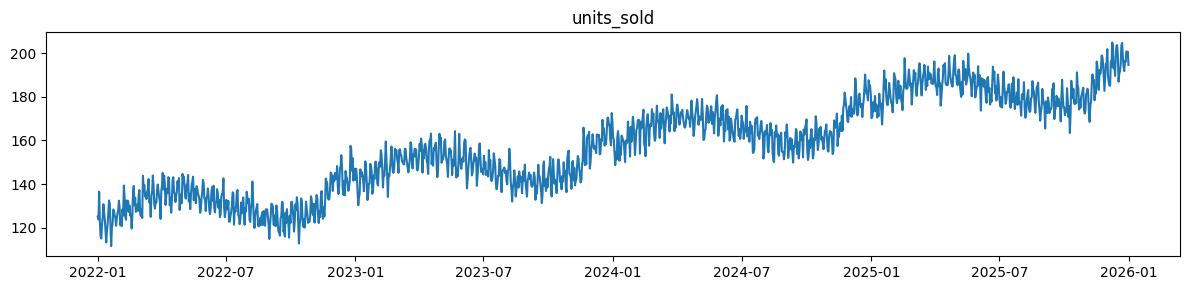

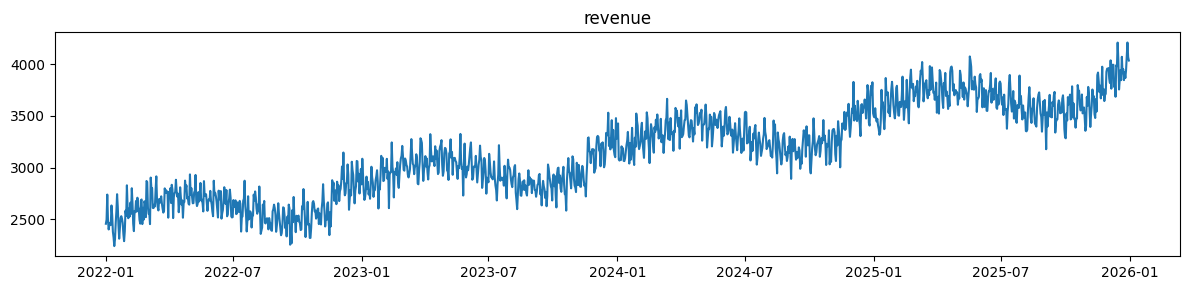

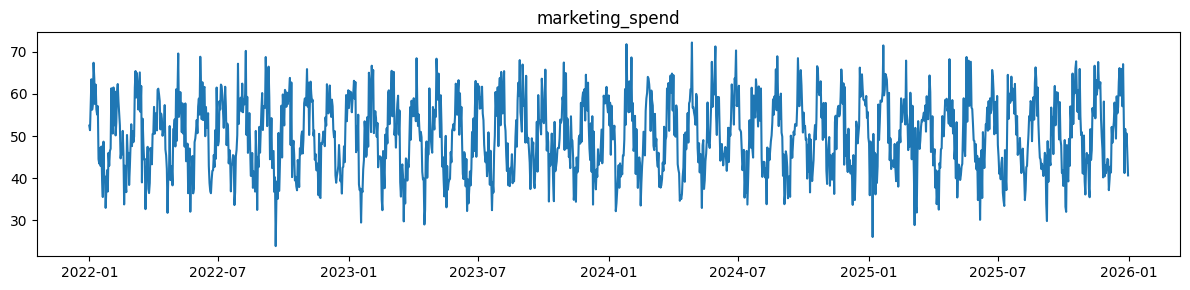

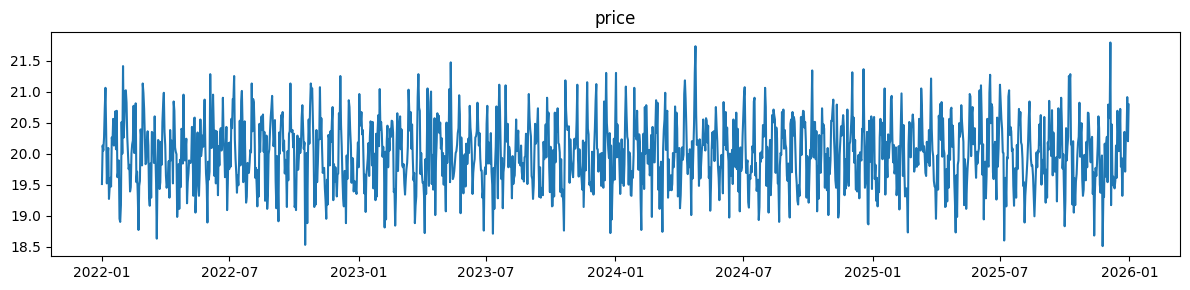

In [11]:
plot_cols = CONFIG["target_cols"] + CONFIG["exogenous_cols"][:2]
for col in plot_cols:
    plt.figure(figsize=(12, 3))
    plt.plot(df_clean[CONFIG["datetime_col"]], df_clean[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()


## 7) Time series diagnostics

ADF test can help you understand whether the target looks stationary.  
For forecasting with machine learning and lag features, strict stationarity is not always required, but the test is still useful.


In [12]:
def adf_test(series: pd.Series, name: str) -> Dict:
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "series": name,
        "adf_stat": result[0],
        "p_value": result[1],
        "used_lag": result[2],
        "n_obs": result[3],
        "stationary_at_5pct": result[1] < 0.05
    }

adf_results = pd.DataFrame([adf_test(df_clean[c], c) for c in CONFIG["target_cols"]])
display(adf_results)


,series,adf_stat,p_value,used_lag,n_obs,stationary_at_5pct
0,units_sold,-0.709065,0.844388,23,1437,False
1,revenue,-0.529364,0.886158,20,1440,False


## 8) Feature engineering

We create:
- calendar features
- lag features
- rolling means / standard deviations

These are generated for both targets and exogenous variables where useful.


In [14]:
def add_calendar_features(df: pd.DataFrame, dt_col: str) -> pd.DataFrame:
    """
    Create new columns based on the datatime column
    """
    df = df.copy()
    dt = pd.to_datetime(df[dt_col])
    df["dayofweek"] = dt.dt.dayofweek
    df["dayofmonth"] = dt.dt.day
    df["month"] = dt.dt.month
    df["quarter"] = dt.dt.quarter
    df["weekofyear"] = dt.dt.isocalendar().week.astype(int)
    df["is_month_start"] = dt.dt.is_month_start.astype(int)
    df["is_month_end"] = dt.dt.is_month_end.astype(int)
    return df

def add_lag_and_rolling_features(df: pd.DataFrame, config: Dict) -> pd.DataFrame:
    df = df.copy()
    base_cols = config["target_cols"] + config["exogenous_cols"]

    for col in base_cols:
        for lag in config["lags"]:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)
        for w in config["rolling_windows"]:
            df[f"{col}_rollmean_{w}"] = df[col].shift(1).rolling(w).mean()
            df[f"{col}_rollstd_{w}"] = df[col].shift(1).rolling(w).std()
    return df

df_feat = add_calendar_features(df_clean, CONFIG["datetime_col"])
df_feat = add_lag_and_rolling_features(df_feat, CONFIG)
print("Feature shape before dropna:", df_feat.shape)
display(df_feat.head())


Feature shape before dropna: (1461, 96)


,date,units_sold,revenue,marketing_spend,price,inventory_level,website_sessions,returns,holiday_flag,dayofweek,...,holiday_flag_lag_1,holiday_flag_lag_7,holiday_flag_lag_14,holiday_flag_lag_28,holiday_flag_rollmean_7,holiday_flag_rollstd_7,holiday_flag_rollmean_14,holiday_flag_rollstd_14,holiday_flag_rollmean_28,holiday_flag_rollstd_28
0,2022-01-01,125.09,2455.80,52.48,19.51,298.83,1049.90,5.10,0.0,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-02,123.83,2495.89,51.39,20.13,302.09,1079.36,9.94,0.0,6,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-03,136.52,2738.15,57.31,20.05,305.25,1107.66,10.82,0.0,0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-04,122.44,2491.80,63.49,20.26,307.99,1058.05,7.41,0.0,1,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-05,116.12,2400.81,56.26,20.72,306.91,952.99,7.32,0.0,2,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9) Supervised learning frame for direct multi-step forecasting

We transform the time series into a tabular problem:

- features at time *t*
- labels are the next `forecast_horizon` steps for each target


In [15]:
def make_supervised_frame(df: pd.DataFrame, config: Dict) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    df = df.copy()
    horizon = config["forecast_horizon"]
    target_cols = config["target_cols"]

    label_cols = []
    for target in target_cols:
        for h in range(1, horizon + 1):
            col_name = f"{target}_tplus_{h}"
            df[col_name] = df[target].shift(-h)
            label_cols.append(col_name)

    df = df.dropna().reset_index(drop=True)

    feature_cols = [c for c in df.columns if c not in label_cols]
    X = df[feature_cols].drop(columns=[config["datetime_col"]])
    y = df[label_cols]
    timestamps = df[config["datetime_col"]]
    return X, y, timestamps

X_all, y_all, ts_all = make_supervised_frame(df_feat, CONFIG)
print("X shape:", X_all.shape)
print("y shape:", y_all.shape)
display(X_all.head())
display(y_all.head())


X shape: (1419, 95)
y shape: (1419, 28)


,units_sold,revenue,marketing_spend,price,inventory_level,website_sessions,returns,holiday_flag,dayofweek,dayofmonth,...,holiday_flag_lag_1,holiday_flag_lag_7,holiday_flag_lag_14,holiday_flag_lag_28,holiday_flag_rollmean_7,holiday_flag_rollstd_7,holiday_flag_rollmean_14,holiday_flag_rollstd_14,holiday_flag_rollmean_28,holiday_flag_rollstd_28
0,126.78,2582.19,42.93,20.51,311.94,1031.90,10.48,0.0,5,29,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,128.01,2532.54,46.46,20.00,307.14,1057.38,9.13,0.0,6,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,132.41,2827.84,46.99,21.41,302.80,1015.66,9.33,0.0,0,31,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,128.63,2619.77,61.34,20.26,306.65,1091.80,8.82,0.0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,121.14,2509.61,54.00,20.56,289.60,1032.85,6.55,0.0,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,units_sold_tplus_1,units_sold_tplus_2,units_sold_tplus_3,units_sold_tplus_4,units_sold_tplus_5,units_sold_tplus_6,units_sold_tplus_7,units_sold_tplus_8,units_sold_tplus_9,units_sold_tplus_10,...,revenue_tplus_5,revenue_tplus_6,revenue_tplus_7,revenue_tplus_8,revenue_tplus_9,revenue_tplus_10,revenue_tplus_11,revenue_tplus_12,revenue_tplus_13,revenue_tplus_14
0,128.01,132.41,128.63,121.14,123.05,120.75,128.55,125.57,139.37,134.01,...,2602.88,2525.91,2659.66,2552.26,2799.58,2652.67,2455.40,2384.61,2578.09,2567.87
1,132.41,128.63,121.14,123.05,120.75,128.55,125.57,139.37,134.01,125.38,...,2525.91,2659.66,2552.26,2799.58,2652.67,2455.40,2384.61,2578.09,2567.87,2676.11
2,128.63,121.14,123.05,120.75,128.55,125.57,139.37,134.01,125.38,123.66,...,2659.66,2552.26,2799.58,2652.67,2455.40,2384.61,2578.09,2567.87,2676.11,2574.09
3,121.14,123.05,120.75,128.55,125.57,139.37,134.01,125.38,123.66,132.53,...,2552.26,2799.58,2652.67,2455.40,2384.61,2578.09,2567.87,2676.11,2574.09,2707.86
4,123.05,120.75,128.55,125.57,139.37,134.01,125.38,123.66,132.53,128.04,...,2799.58,2652.67,2455.40,2384.61,2578.09,2567.87,2676.11,2574.09,2707.86,2621.35


## 10) Train / validation / test split

We keep the last `test_size` observations as a strict holdout.


In [16]:
def temporal_train_test_split(X, y, ts, test_size: int):
    split_idx = len(X) - test_size
    return (
        X.iloc[:split_idx].copy(),
        X.iloc[split_idx:].copy(),
        y.iloc[:split_idx].copy(),
        y.iloc[split_idx:].copy(),
        ts.iloc[:split_idx].copy(),
        ts.iloc[split_idx:].copy(),
    )

X_train, X_test, y_train, y_test, ts_train, ts_test = temporal_train_test_split(
    X_all, y_all, ts_all, CONFIG["test_size"]
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train date range:", ts_train.min(), "to", ts_train.max())
print("Test date range:", ts_test.min(), "to", ts_test.max())


Train rows: 1359
Test rows: 60
Train date range: 2022-01-29 00:00:00 to 2025-10-18 00:00:00
Test date range: 2025-10-19 00:00:00 to 2025-12-17 00:00:00


## 11) Model

A simple but strong baseline:
- `StandardScaler`
- `Ridge`
- wrapped with `MultiOutputRegressor` for all targets and horizons

You can replace this with XGBoost, LightGBM, CatBoost, RandomForest, or deep learning later.


In [17]:
def build_model():
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", MultiOutputRegressor(Ridge(alpha=1.0)))
    ])
    return model

model = build_model()
model.fit(X_train, y_train)
pred_test = pd.DataFrame(model.predict(X_test), columns=y_test.columns, index=y_test.index)

display(pred_test.head())


,units_sold_tplus_1,units_sold_tplus_2,units_sold_tplus_3,units_sold_tplus_4,units_sold_tplus_5,units_sold_tplus_6,units_sold_tplus_7,units_sold_tplus_8,units_sold_tplus_9,units_sold_tplus_10,...,revenue_tplus_5,revenue_tplus_6,revenue_tplus_7,revenue_tplus_8,revenue_tplus_9,revenue_tplus_10,revenue_tplus_11,revenue_tplus_12,revenue_tplus_13,revenue_tplus_14
1359,187.316570,182.850796,175.755357,169.884061,168.978211,177.558819,183.886347,188.179885,186.263123,179.616212,...,3456.800798,3557.686834,3650.870582,3691.114396,3605.135647,3470.978093,3396.016491,3423.881499,3527.221585,3749.322336
1360,174.411342,170.499062,170.763525,175.468890,182.001404,184.344317,182.891517,177.617394,173.873531,175.502867,...,3661.340115,3692.515722,3625.713705,3480.092380,3362.891718,3389.914724,3507.048521,3636.845107,3728.440851,3726.293975
1361,174.344988,172.457029,173.371465,176.851223,179.916705,182.413350,182.564040,179.036899,177.141630,177.241498,...,3586.411520,3580.879089,3540.614688,3466.040873,3393.036300,3430.353488,3552.737676,3677.655970,3692.025698,3730.265441
1362,174.898221,175.167234,177.507841,178.396144,180.256904,181.227091,178.599364,178.304245,178.532296,179.120280,...,3570.484835,3533.585573,3483.985969,3469.030985,3485.038256,3533.976808,3652.580834,3673.113916,3691.690267,3642.519074
1363,172.833906,178.417816,181.702563,181.871151,179.230206,176.425527,175.268494,177.694066,181.127264,183.187094,...,3510.315929,3449.880101,3421.812604,3523.192372,3579.778213,3683.255062,3716.800845,3668.157872,3577.921367,3565.866162


## 12) Metrics

In [18]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_multistep(y_true: pd.DataFrame, y_pred: pd.DataFrame, target_cols: List[str], horizon: int) -> pd.DataFrame:
    rows = []
    for target in target_cols:
        for h in range(1, horizon + 1):
            col = f"{target}_tplus_{h}"
            rows.append({
                "target": target,
                "horizon": h,
                "MAE": mean_absolute_error(y_true[col], y_pred[col]),
                "RMSE": rmse(y_true[col], y_pred[col])
            })
    return pd.DataFrame(rows)

test_metrics = evaluate_multistep(y_test, pred_test, CONFIG["target_cols"], CONFIG["forecast_horizon"])
display(test_metrics.head(10))
display(test_metrics.groupby("target")[["MAE", "RMSE"]].mean().round(3))


,target,horizon,MAE,RMSE
0,units_sold,1,4.206839,5.401935
1,units_sold,2,4.028156,5.372376
2,units_sold,3,4.041666,5.440713
3,units_sold,4,4.130139,5.770829
4,units_sold,5,4.485801,5.848236
5,units_sold,6,4.356098,5.360057
6,units_sold,7,4.372003,5.673782
7,units_sold,8,4.595816,5.940417
8,units_sold,9,4.836291,6.145050
9,units_sold,10,5.042370,6.316553


,MAE,RMSE
target,,
revenue,89.802,110.770
units_sold,4.602,5.972


## 13) Rolling-origin backtesting

This is the most important part for forecasting validation.  
Each fold trains on the past and predicts the next horizon window.


In [19]:
def run_backtest(X: pd.DataFrame, y: pd.DataFrame, timestamps: pd.Series, config: Dict) -> pd.DataFrame:
    horizon = config["forecast_horizon"]
    n_folds = config["n_backtest_folds"]
    step = config["backtest_step"]

    results = []

    # Start far enough back so we have n_folds evaluation windows
    last_train_end = len(X) - (n_folds * step) - 1
    if last_train_end <= 50:
        raise ValueError("Not enough rows for requested backtest settings.")

    for fold in range(n_folds):
        train_end = last_train_end + fold * step
        test_start = train_end + 1
        test_end = test_start + step

        X_tr = X.iloc[:train_end].copy()
        y_tr = y.iloc[:train_end].copy()
        X_val = X.iloc[test_start:test_end].copy()
        y_val = y.iloc[test_start:test_end].copy()
        ts_val = timestamps.iloc[test_start:test_end].copy()

        model = build_model()
        model.fit(X_tr, y_tr)
        pred_val = pd.DataFrame(model.predict(X_val), columns=y.columns, index=y_val.index)

        fold_metrics = evaluate_multistep(y_val, pred_val, config["target_cols"], horizon)
        fold_metrics["fold"] = fold + 1
        fold_metrics["forecast_start"] = ts_val.min()
        fold_metrics["forecast_end"] = ts_val.max()
        results.append(fold_metrics)

    return pd.concat(results, ignore_index=True)

backtest_results = run_backtest(X_train, y_train, ts_train, CONFIG)
display(backtest_results.head(10))
display(backtest_results.groupby(["fold", "target"])[["MAE", "RMSE"]].mean().round(3))


,target,horizon,MAE,RMSE,fold,forecast_start,forecast_end
0,units_sold,1,3.522799,4.325664,1,2025-08-24,2025-09-06
1,units_sold,2,3.995857,4.695211,1,2025-08-24,2025-09-06
2,units_sold,3,3.692844,4.516301,1,2025-08-24,2025-09-06
3,units_sold,4,3.373215,4.359003,1,2025-08-24,2025-09-06
4,units_sold,5,3.351460,4.077607,1,2025-08-24,2025-09-06
5,units_sold,6,3.313100,4.750107,1,2025-08-24,2025-09-06
6,units_sold,7,3.768408,4.802373,1,2025-08-24,2025-09-06
7,units_sold,8,3.775756,4.929995,1,2025-08-24,2025-09-06
8,units_sold,9,3.091770,4.379505,1,2025-08-24,2025-09-06
9,units_sold,10,3.686604,4.815946,1,2025-08-24,2025-09-06


MAE     RMSE
fold target                     
1    revenue     99.947  122.825
     units_sold   3.569    4.606
2    revenue     70.138   88.324
     units_sold   2.977    3.745
3    revenue     89.640  112.320
     units_sold   3.681    4.698
4    revenue     66.890   85.535
     units_sold   3.433    4.485

In [20]:
bt_summary = (
    backtest_results
    .groupby(["target", "horizon"])[["MAE", "RMSE"]]
    .mean()
    .reset_index()
)
display(bt_summary.head(20))
display(bt_summary.groupby("target")[["MAE", "RMSE"]].mean().round(3))


,target,horizon,MAE,RMSE
0,revenue,1,93.447935,115.942963
1,revenue,2,79.481219,100.493139
2,revenue,3,78.583460,96.829141
3,revenue,4,76.840660,95.851064
4,revenue,5,87.203763,108.045318
5,revenue,6,86.647218,108.764883
6,revenue,7,81.371360,100.636190
7,revenue,8,89.502547,110.470529
8,revenue,9,75.253171,100.049972
9,revenue,10,74.075354,95.995415


,MAE,RMSE
target,,
revenue,81.654,102.251
units_sold,3.415,4.384


## 14) Plot actual vs predicted for one horizon

Below we plot the first-step forecast (`t+1`) for each target on the holdout test set.


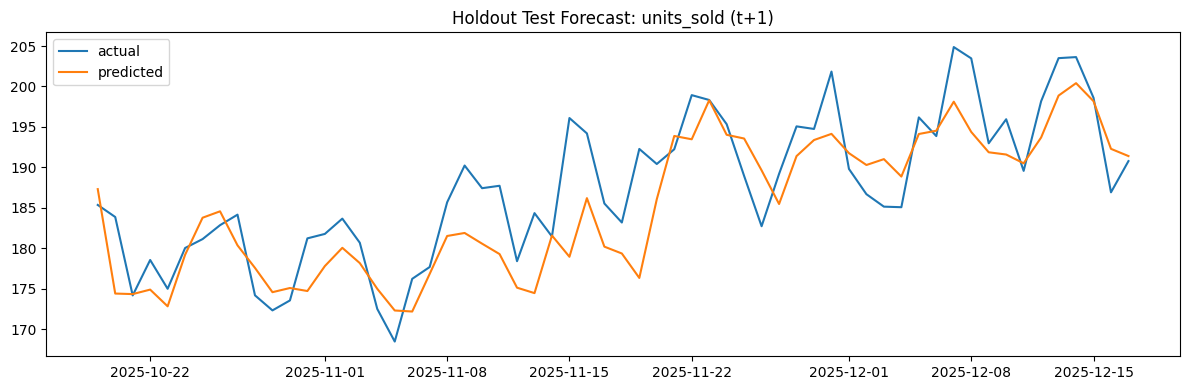

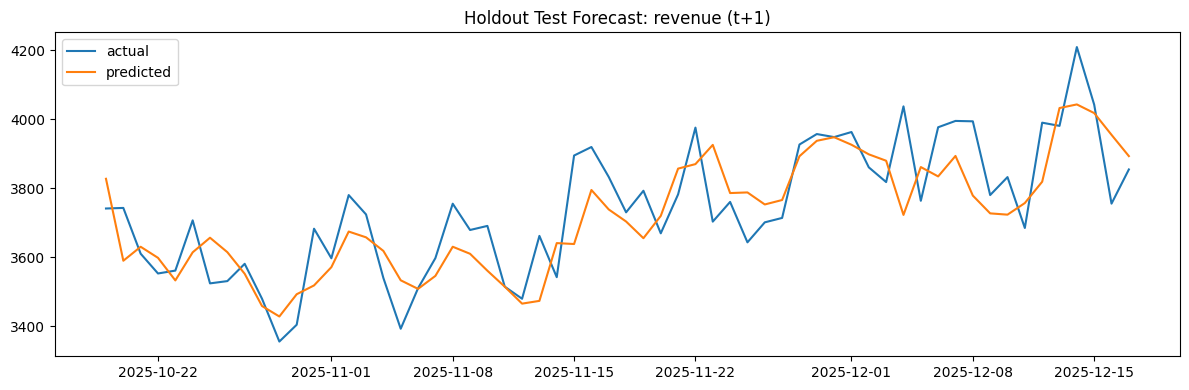

In [21]:
for target in CONFIG["target_cols"]:
    col = f"{target}_tplus_1"
    plt.figure(figsize=(12, 4))
    plt.plot(ts_test, y_test[col], label="actual")
    plt.plot(ts_test, pred_test[col], label="predicted")
    plt.title(f"Holdout Test Forecast: {target} (t+1)")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 15) What to test before production

Use this checklist before moving a forecasting pipeline into production:

### Data tests
- datetime column parses correctly
- no duplicate timestamps after regularization
- target columns exist and are numeric
- expected frequency is correct
- missingness stays within acceptable thresholds
- future leakage is not introduced in lag/rolling features

### Modeling tests
- backtest performance is stable across folds
- error does not explode at longer horizons
- baseline comparison beats naive forecasts
- feature generation is reproducible on new data

### Operational tests
- schema validation for new files
- retraining schedule is defined
- prediction logging is enabled
- drift monitoring for exogenous variables and target residuals


## 16) Optional next improvements

You can upgrade this notebook by:
- replacing Ridge with LightGBM / XGBoost / CatBoost
- adding naive and seasonal-naive baselines
- using separate models per target
- adding probabilistic forecasts (quantiles)
- adding Optuna hyperparameter tuning
- adding SHAP-based feature importance
- using dedicated libraries such as `darts`, `sktime`, `statsforecast`, or `mlforecast`


## 17) Export predictions

In [22]:
forecast_output = pd.concat(
    [
        ts_test.reset_index(drop=True).rename("timestamp"),
        y_test.reset_index(drop=True).add_prefix("actual_"),
        pred_test.reset_index(drop=True).add_prefix("pred_")
    ],
    axis=1
)

forecast_output_path = "forecast_holdout_predictions.csv"
forecast_output.to_csv(forecast_output_path, index=False)

print("Saved:", forecast_output_path)
display(forecast_output.head())


Saved: forecast_holdout_predictions.csv


,timestamp,actual_units_sold_tplus_1,actual_units_sold_tplus_2,actual_units_sold_tplus_3,actual_units_sold_tplus_4,actual_units_sold_tplus_5,actual_units_sold_tplus_6,actual_units_sold_tplus_7,actual_units_sold_tplus_8,actual_units_sold_tplus_9,...,pred_revenue_tplus_5,pred_revenue_tplus_6,pred_revenue_tplus_7,pred_revenue_tplus_8,pred_revenue_tplus_9,pred_revenue_tplus_10,pred_revenue_tplus_11,pred_revenue_tplus_12,pred_revenue_tplus_13,pred_revenue_tplus_14
0,2025-10-19,185.36,183.87,174.18,178.56,175.00,180.04,181.14,182.86,184.16,...,3456.800798,3557.686834,3650.870582,3691.114396,3605.135647,3470.978093,3396.016491,3423.881499,3527.221585,3749.322336
1,2025-10-20,183.87,174.18,178.56,175.00,180.04,181.14,182.86,184.16,174.19,...,3661.340115,3692.515722,3625.713705,3480.092380,3362.891718,3389.914724,3507.048521,3636.845107,3728.440851,3726.293975
2,2025-10-21,174.18,178.56,175.00,180.04,181.14,182.86,184.16,174.19,172.33,...,3586.411520,3580.879089,3540.614688,3466.040873,3393.036300,3430.353488,3552.737676,3677.655970,3692.025698,3730.265441
3,2025-10-22,178.56,175.00,180.04,181.14,182.86,184.16,174.19,172.33,173.56,...,3570.484835,3533.585573,3483.985969,3469.030985,3485.038256,3533.976808,3652.580834,3673.113916,3691.690267,3642.519074
4,2025-10-23,175.00,180.04,181.14,182.86,184.16,174.19,172.33,173.56,181.23,...,3510.315929,3449.880101,3421.812604,3523.192372,3579.778213,3683.255062,3716.800845,3668.157872,3577.921367,3565.866162


## 18) Strong baseline models and leakage checks

In [23]:

def check_temporal_leakage(feature_frame: pd.DataFrame, config: Dict) -> pd.DataFrame:
    suspicious_patterns = ["tplus_", "lead_", "future", "next_", "_fwd", "tomorrow"]
    flagged = []
    for col in feature_frame.columns:
        lowered = col.lower()
        if any(p in lowered for p in suspicious_patterns):
            flagged.append({"feature": col, "reason": "Potential future-looking name pattern"})
    return pd.DataFrame(flagged)

leakage_report = check_temporal_leakage(X_all, CONFIG)
if leakage_report.empty:
    print("Leakage name-pattern check: no suspicious feature names found.")
else:
    display(leakage_report)

assert ts_train.max() < ts_test.min(), "Temporal split is invalid: train overlaps with test."
print("Temporal split check passed.")


Leakage name-pattern check: no suspicious feature names found.
Temporal split check passed.


In [24]:

def safe_mape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def smape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100

def wape(y_true, y_pred, eps: float = 1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps) * 100

def mase(y_true, y_pred, insample, seasonality: int = 1, eps: float = 1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    insample = np.asarray(insample)
    if len(insample) <= seasonality:
        return np.nan
    naive_errors = np.abs(insample[seasonality:] - insample[:-seasonality])
    scale = np.mean(naive_errors) if len(naive_errors) else np.nan
    if np.isnan(scale) or scale < eps:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / scale

def evaluate_univariate_forecast(y_true, y_pred, insample, seasonality: int = 1) -> Dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": safe_mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "MASE": mase(y_true, y_pred, insample=insample, seasonality=seasonality),
    }

def build_baseline_predictions(train_series: pd.Series, test_series: pd.Series, seasonality: int = 7, moving_avg_window: int = 7) -> pd.DataFrame:
    train_series = train_series.astype(float)
    test_index = test_series.index

    last_value = float(train_series.iloc[-1])
    naive_pred = pd.Series([last_value] * len(test_series), index=test_index)

    if len(train_series) >= seasonality:
        seasonal_values = train_series.iloc[-seasonality:].to_numpy()
        seasonal_pred = pd.Series(
            [float(seasonal_values[i % seasonality]) for i in range(len(test_series))],
            index=test_index
        )
    else:
        seasonal_pred = naive_pred.copy()

    ma_value = float(train_series.iloc[-moving_avg_window:].mean())
    moving_avg_pred = pd.Series([ma_value] * len(test_series), index=test_index)

    return pd.DataFrame({
        "naive": naive_pred,
        "seasonal_naive": seasonal_pred,
        "moving_average": moving_avg_pred
    })

SEASONALITY = 7 if CONFIG["freq"].upper().startswith("D") else 12
baseline_rows = []

for target in CONFIG["target_cols"]:
    target_col = f"{target}_tplus_1"
    actual = y_test[target_col]
    insample = y_train[target_col]
    baselines = build_baseline_predictions(insample, actual, seasonality=SEASONALITY, moving_avg_window=min(7, len(insample)))

    for model_name in baselines.columns:
        metrics = evaluate_univariate_forecast(actual, baselines[model_name], insample=insample, seasonality=SEASONALITY)
        baseline_rows.append({
            "target": target,
            "model": model_name,
            **metrics
        })

baseline_metrics = pd.DataFrame(baseline_rows).round(4)
display(baseline_metrics)


,target,model,MAE,RMSE,MAPE,sMAPE,WAPE,MASE
0,units_sold,naive,7.9542,9.5657,4.3290,4.2396,4.2433,1.8041
1,units_sold,seasonal_naive,9.0827,11.1687,4.7351,4.8850,4.8453,2.0601
2,units_sold,moving_average,9.0995,11.2051,4.7360,4.8806,4.8543,2.0639
3,revenue,naive,159.1070,192.6807,4.3235,4.2513,4.2541,1.4053
4,revenue,seasonal_naive,238.5403,284.6005,6.2384,6.5045,6.3779,2.1068
5,revenue,moving_average,230.8970,280.6776,5.9948,6.2545,6.1735,2.0393


## 19) Compare ML holdout results against baseline models (t+1 horizon)

In [25]:

ml_rows = []
for target in CONFIG["target_cols"]:
    target_col = f"{target}_tplus_1"
    actual = y_test[target_col]
    predicted = pred_test[target_col]
    insample = y_train[target_col]

    ml_rows.append({
        "target": target,
        "model": "ridge_direct_multistep",
        **evaluate_univariate_forecast(actual, predicted, insample=insample, seasonality=SEASONALITY)
    })

ml_t1_metrics = pd.DataFrame(ml_rows)
comparison_metrics = pd.concat([baseline_metrics, ml_t1_metrics], ignore_index=True).round(4)
display(comparison_metrics.sort_values(["target", "RMSE", "MAE"]))


,target,model,MAE,RMSE,MAPE,sMAPE,WAPE,MASE
7,revenue,ridge_direct_multistep,90.4152,112.2531,2.3988,2.4142,2.4174,0.7986
3,revenue,naive,159.1070,192.6807,4.3235,4.2513,4.2541,1.4053
5,revenue,moving_average,230.8970,280.6776,5.9948,6.2545,6.1735,2.0393
4,revenue,seasonal_naive,238.5403,284.6005,6.2384,6.5045,6.3779,2.1068
6,units_sold,ridge_direct_multistep,4.2068,5.4019,2.2289,2.2590,2.2442,0.9542
0,units_sold,naive,7.9542,9.5657,4.3290,4.2396,4.2433,1.8041
1,units_sold,seasonal_naive,9.0827,11.1687,4.7351,4.8850,4.8453,2.0601
2,units_sold,moving_average,9.0995,11.2051,4.7360,4.8806,4.8543,2.0639


## 20) SARIMAX baseline with confidence intervals and diagnostics

In [26]:

import itertools
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

target_for_sarimax = CONFIG["target_cols"][0]
exog_cols = CONFIG["exogenous_cols"]
seasonal_period = 7 if CONFIG["freq"].upper().startswith("D") else 12

series_train = df_clean.set_index(CONFIG["datetime_col"])[target_for_sarimax].iloc[:-CONFIG["test_size"]]
series_test = df_clean.set_index(CONFIG["datetime_col"])[target_for_sarimax].iloc[-CONFIG["test_size"]:]
exog_full = df_clean.set_index(CONFIG["datetime_col"])[exog_cols]
exog_train = exog_full.iloc[:-CONFIG["test_size"]]
exog_test = exog_full.iloc[-CONFIG["test_size"]:]

p = d = q = range(0, 2)
pdq_grid = list(itertools.product(p, d, q))
seasonal_grid = [(P, D, Q, seasonal_period) for P, D, Q in itertools.product(range(0, 2), range(0, 2), range(0, 2))]

search_rows = []
best_aic = np.inf
best_cfg = None
best_result = None

for order in pdq_grid:
    for seasonal_order in seasonal_grid:
        try:
            model = sm.tsa.statespace.SARIMAX(
                series_train,
                exog=exog_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            result = model.fit(disp=False)
            search_rows.append({
                "order": str(order),
                "seasonal_order": str(seasonal_order),
                "AIC": result.aic,
                "BIC": result.bic
            })
            if result.aic < best_aic:
                best_aic = result.aic
                best_cfg = (order, seasonal_order)
                best_result = result
        except Exception:
            continue

sarimax_search = pd.DataFrame(search_rows).sort_values("AIC").reset_index(drop=True)
display(sarimax_search.head(10))
print("Best SARIMAX config:", best_cfg)


/Users/kevin/Programming/Mahendra-Notebooks/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kevin/Programming/Mahendra-Notebooks/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kevin/Programming/Mahendra-Notebooks/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kevin/Programming/Mahendra-Notebooks/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kevin/Programming/Mahendra-No

,order,seasonal_order,AIC,BIC
0,"(1, 1, 1)","(0, 1, 1, 7)",7269.587865,7321.915197
1,"(1, 1, 1)","(1, 1, 1, 7)",7271.703159,7329.263224
2,"(0, 1, 1)","(0, 1, 1, 7)",7277.436854,7324.531452
3,"(0, 1, 1)","(1, 1, 1, 7)",7280.318767,7332.646098
4,"(1, 0, 1)","(0, 1, 1, 7)",7284.221053,7336.555607
5,"(1, 0, 1)","(1, 1, 1, 7)",7285.946010,7343.514019
6,"(1, 1, 1)","(1, 0, 1, 7)",7306.773357,7364.388917
7,"(0, 1, 1)","(1, 0, 1, 7)",7315.188293,7367.566075
8,"(0, 1, 1)","(0, 0, 1, 7)",7578.064204,7625.204208
9,"(1, 1, 1)","(1, 0, 0, 7)",7578.974588,7631.359556


Best SARIMAX config: ((1, 1, 1), (0, 1, 1, 7))


,target,model,MAE,RMSE,MAPE,sMAPE,WAPE,MASE
0,units_sold,sarimax_tuned,5.2548,6.1389,2.6997,2.7482,2.7444,1.2001


,lower units_sold,upper units_sold
2025-11-02,175.951302,188.849035
2025-11-03,176.001642,188.956816
2025-11-04,173.555407,186.723883
2025-11-05,169.421960,182.781091
2025-11-06,164.424666,177.973586


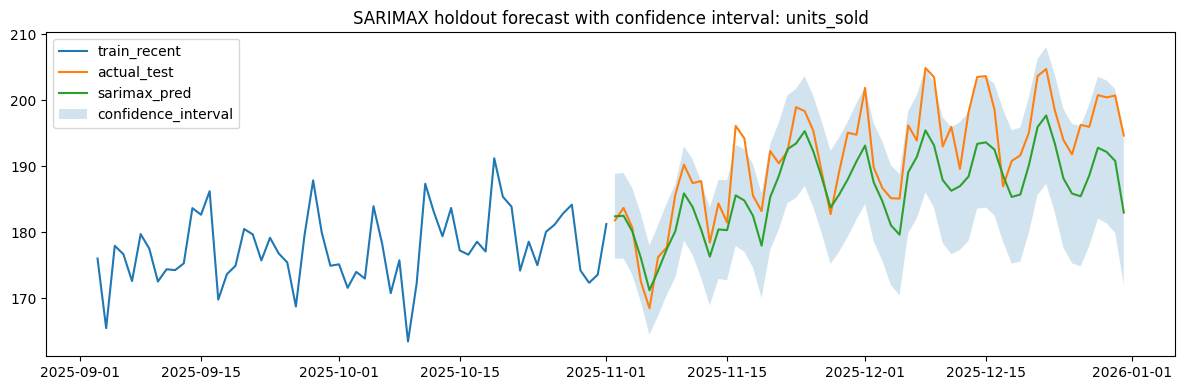

In [28]:

sarimax_forecast = best_result.get_forecast(steps=len(series_test), exog=exog_test)
sarimax_pred = sarimax_forecast.predicted_mean
sarimax_ci = sarimax_forecast.conf_int()

sarimax_holdout_metrics = pd.DataFrame([{
    "target": target_for_sarimax,
    "model": "sarimax_tuned",
    **evaluate_univariate_forecast(series_test, sarimax_pred, insample=series_train, seasonality=seasonal_period)
}]).round(4)

display(sarimax_holdout_metrics)
display(sarimax_ci.head())

plt.figure(figsize=(12, 4))
plt.plot(series_train.index[-60:], series_train.tail(60), label="train_recent")
plt.plot(series_test.index, series_test, label="actual_test")
plt.plot(series_test.index, sarimax_pred, label="sarimax_pred")
plt.fill_between(
    series_test.index,
    sarimax_ci.iloc[:, 0],
    sarimax_ci.iloc[:, 1],
    alpha=0.2,
    label="confidence_interval"
)
plt.title(f"SARIMAX holdout forecast with confidence interval: {target_for_sarimax}")
plt.legend()
plt.tight_layout()
plt.show()


## 21) Residual diagnostics for the tuned SARIMAX model

,metric,value
0,residual_mean,-0.0396
1,residual_std,5.6997
2,residual_skew,8.0619
3,residual_kurtosis,341.0266


,lb_stat,lb_pvalue
10,148.3441,0.0


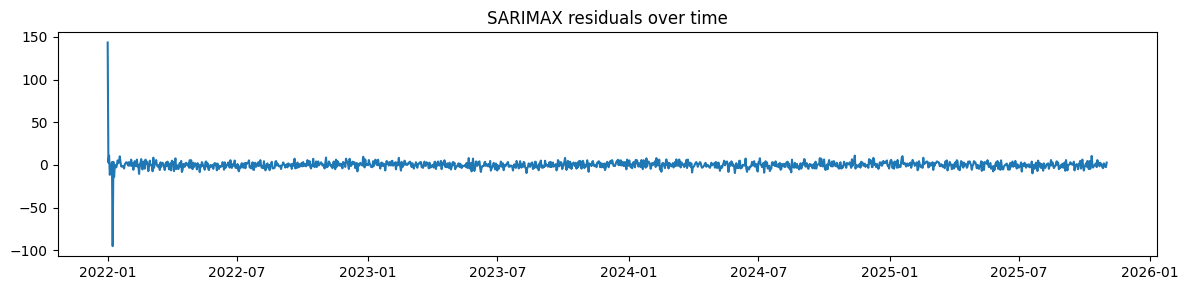

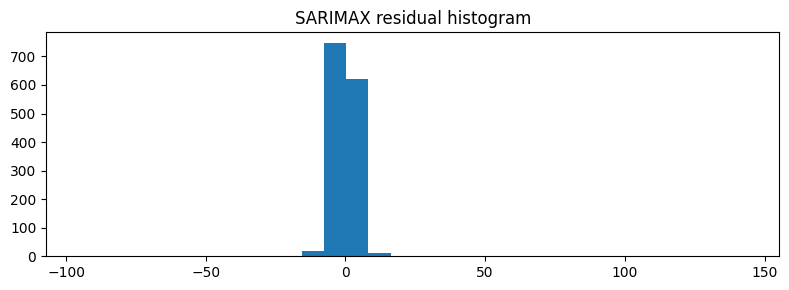

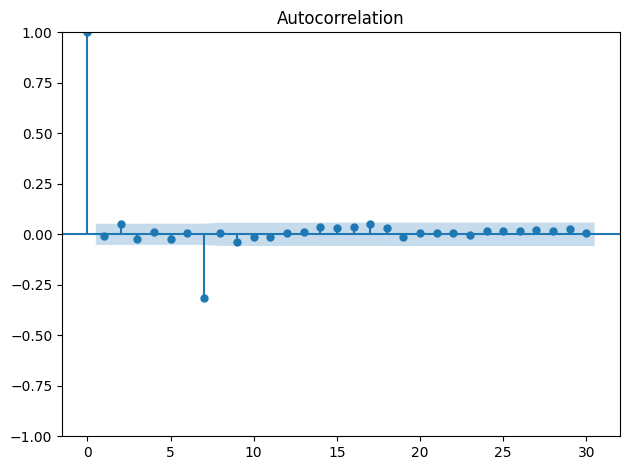

In [29]:

residuals = pd.Series(best_result.resid).dropna()

ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
residual_summary = pd.DataFrame({
    "metric": ["residual_mean", "residual_std", "residual_skew", "residual_kurtosis"],
    "value": [
        residuals.mean(),
        residuals.std(),
        residuals.skew(),
        residuals.kurtosis()
    ]
})

display(residual_summary.round(4))
display(ljung_box.round(4))

plt.figure(figsize=(12, 3))
plt.plot(residuals.index, residuals.values)
plt.title("SARIMAX residuals over time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.hist(residuals, bins=30)
plt.title("SARIMAX residual histogram")
plt.tight_layout()
plt.show()

plot_acf(residuals, lags=30)
plt.tight_layout()
plt.show()


## 22) Backtest error trend view

,fold,target,MAE,RMSE
0,1,revenue,99.9468,122.8245
1,1,units_sold,3.5689,4.6061
2,2,revenue,70.1380,88.3235
3,2,units_sold,2.9774,3.7451
4,3,revenue,89.6396,112.3205
5,3,units_sold,3.6808,4.6983
6,4,revenue,66.8900,85.5348
7,4,units_sold,3.4335,4.4853


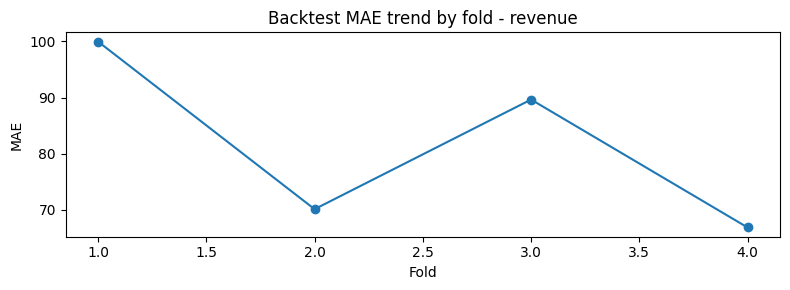

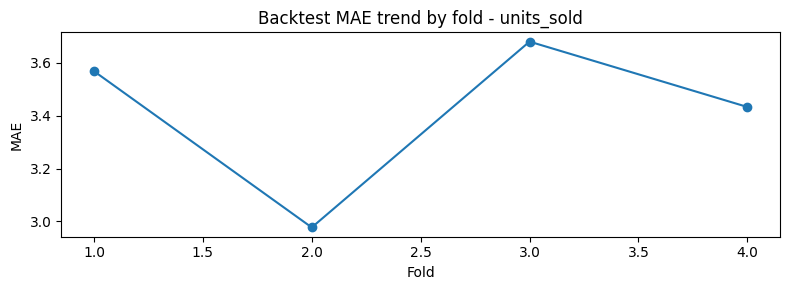

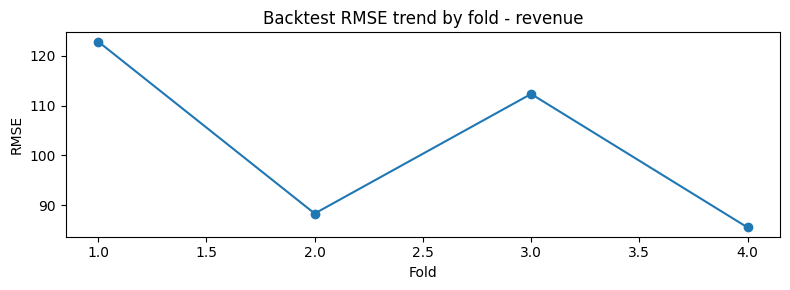

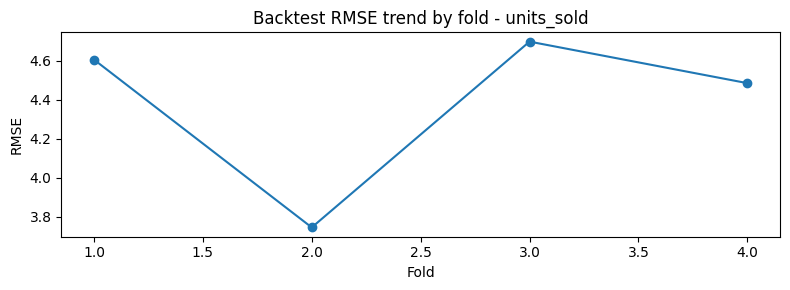

In [30]:

bt_error_trend = (
    backtest_results
    .groupby(["fold", "target"])[["MAE", "RMSE"]]
    .mean()
    .reset_index()
)

display(bt_error_trend.round(4))

for metric in ["MAE", "RMSE"]:
    for target in bt_error_trend["target"].unique():
        subset = bt_error_trend[bt_error_trend["target"] == target]
        plt.figure(figsize=(8, 3))
        plt.plot(subset["fold"], subset[metric], marker="o")
        plt.title(f"Backtest {metric} trend by fold - {target}")
        plt.xlabel("Fold")
        plt.ylabel(metric)
        plt.tight_layout()
        plt.show()


## 23) Optional true multivariate statistical model scaffold (VARMAX)

In [ ]:

# This cell is intentionally lightweight.
# Use it when you want a true multivariate statistical model where multiple targets
# are modeled jointly rather than one target at a time.
#
# Example scaffold:
#
# from statsmodels.tsa.statespace.varmax import VARMAX
#
# joint_train = df_clean.set_index(CONFIG["datetime_col"])[CONFIG["target_cols"]].iloc[:-CONFIG["test_size"]]
# joint_test = df_clean.set_index(CONFIG["datetime_col"])[CONFIG["target_cols"]].iloc[-CONFIG["test_size"]:]
# exog_train_joint = df_clean.set_index(CONFIG["datetime_col"])[CONFIG["exogenous_cols"]].iloc[:-CONFIG["test_size"]]
# exog_test_joint = df_clean.set_index(CONFIG["datetime_col"])[CONFIG["exogenous_cols"]].iloc[-CONFIG["test_size"]:]
#
# varmax_model = VARMAX(
#     endog=joint_train,
#     exog=exog_train_joint,
#     order=(1, 1),
#     trend="c"
# )
# varmax_result = varmax_model.fit(maxiter=200, disp=False)
# varmax_forecast = varmax_result.forecast(steps=len(joint_test), exog=exog_test_joint)
#
# display(varmax_forecast.head())
#
print("VARMAX scaffold added. Uncomment and run on sufficiently large datasets for true joint-target modeling.")
